# EDA — IEEE-CIS Fraud Detection

Exploration only — no modelling logic lives here long-term (see `src/`). This dataset is the **feature-engineering showcase**, not the served model (see project README "Why two datasets") — the focus here is different from the Kaggle EDA notebook: categorical cardinality, missing-data patterns, and the engineered features in `src/data/preprocess_ieee.py`, rather than raw PCA-component distributions.

In [1]:
import sys
from pathlib import Path


def find_project_root(marker: str = "requirements.txt") -> Path:
    path = Path.cwd()
    for parent in [path, *path.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not locate project root (missing {marker})")


project_root = find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from src.data.load import load_raw_ieee_data
from src.data.preprocess_ieee import (
    CATEGORICAL_COLUMNS,
    engineer_features,
    join_transaction_identity,
    time_aware_split,
)

# Same fixed categorical slots as the Kaggle notebook, so "legitimate" and
# "fraud" mean the same two colors across the whole project.
COLOR_LEGIT = "#2a78d6"
COLOR_FRAUD = "#e34948"
COLOR_SEQUENTIAL = "#2a78d6"
COLOR_MUTED = "#898781"
COLOR_GRID = "#e1e0d9"

plt.rcParams.update(
    {
        "figure.facecolor": "#fcfcfb",
        "axes.facecolor": "#fcfcfb",
        "axes.edgecolor": COLOR_MUTED,
        "axes.grid": True,
        "grid.color": COLOR_GRID,
        "grid.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

transaction_df, identity_df = load_raw_ieee_data()
print(f"transaction: {transaction_df.shape}, identity: {identity_df.shape}")

transaction: (590540, 394), identity: (144233, 41)


## Structure & join coverage

In [2]:
joined = join_transaction_identity(transaction_df, identity_df)

print(f"Joined shape: {joined.shape}")
print(f"Transactions with a matching identity row: {joined['has_identity'].mean() * 100:.1f}%")
print(f"Fraud rate (whole dataset): {joined['isFraud'].mean() * 100:.3f}%")
print(f"Duplicate TransactionIDs: {joined['TransactionID'].duplicated().sum()}")

Joined shape: (590540, 435)
Transactions with a matching identity row: 24.4%
Fraud rate (whole dataset): 3.499%
Duplicate TransactionIDs: 0


/home/tehsh/pythonProjects/fraudDetection/src/data/preprocess_ieee.py:52: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined["has_identity"] = joined["TransactionID"].isin(identity_df["TransactionID"]).astype(int)


Two structural differences from the Kaggle dataset worth flagging up front: fraud is ~20x more common here (3.5% vs 0.17%), and three-quarters of transactions have **no** identity record at all — that's not a per-field missing value, it's a whole different data-collection situation (e.g. guest checkout vs. a logged-in session with a device fingerprint), which is why `has_identity` is engineered as its own feature rather than left implicit.

## Class imbalance

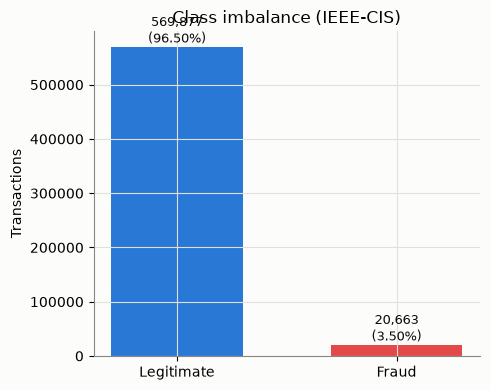

In [3]:
counts = joined["isFraud"].value_counts().sort_index()
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Legitimate", "Fraud"], counts.values, color=[COLOR_LEGIT, COLOR_FRAUD], width=0.6)
for bar, count, p in zip(bars, counts.values, pct.values):
    ax.annotate(
        f"{count:,}\n({p:.2f}%)",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
        color="#0b0b0b",
    )
ax.set_ylabel("Transactions")
ax.set_title("Class imbalance (IEEE-CIS)")
plt.tight_layout()
plt.show()

Still highly imbalanced, but far less extreme than the Kaggle dataset — PR-AUC remains the right headline metric here too, but the two datasets sit at different points on the imbalance spectrum, which is itself a useful thing to be able to say in an interview.

## Categorical cardinality

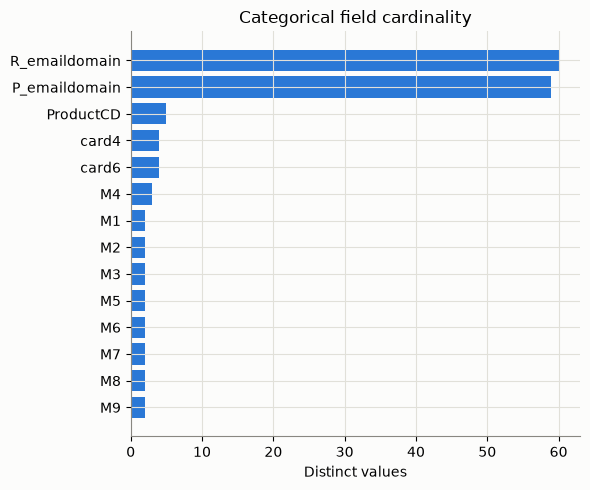

R_emaildomain    60
P_emaildomain    59
ProductCD         5
card4             4
card6             4
M4                3
M1                2
M2                2
M3                2
M5                2
M6                2
M7                2
M8                2
M9                2
dtype: int64

In [4]:
cardinality = joined[CATEGORICAL_COLUMNS].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 5))
ax.barh(cardinality.index[::-1], cardinality.values[::-1], color=COLOR_SEQUENTIAL)
ax.set_xlabel("Distinct values")
ax.set_title("Categorical field cardinality")
plt.tight_layout()
plt.show()

cardinality

Cardinality is low-to-moderate across the board (max 60, for email domains) — small enough that `preprocess_ieee.py` uses plain label/category-code encoding fit on the training split (`fit_feature_encoders`), rather than needing target encoding or hashing to control dimensionality.

## Missing-data patterns

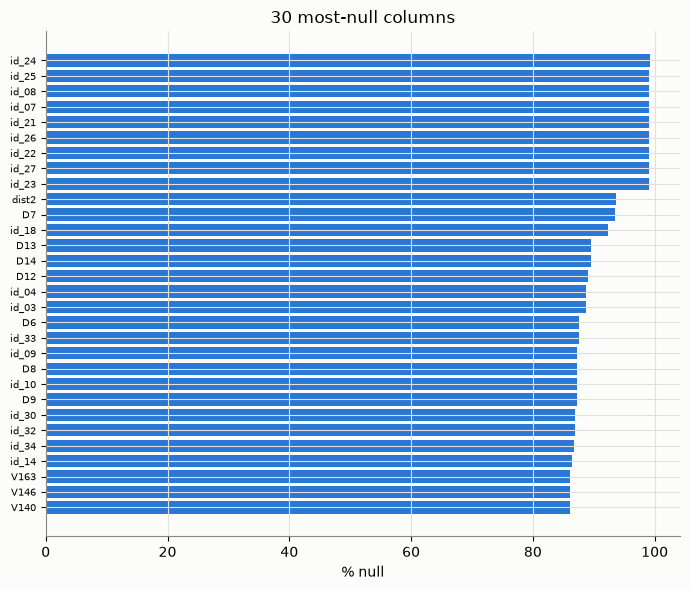

Columns >50% null: 214 / 434
Columns >90% null: 12 / 434


In [5]:
null_fraction = joined.drop(columns=["isFraud"]).isnull().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
top30 = null_fraction.head(30)
ax.barh(top30.index[::-1], top30.values[::-1] * 100, color=COLOR_SEQUENTIAL)
ax.set_xlabel("% null")
ax.set_title("30 most-null columns")
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.show()

print(f"Columns >50% null: {(null_fraction > 0.5).sum()} / {len(null_fraction)}")
print(f"Columns >90% null: {(null_fraction > 0.9).sum()} / {len(null_fraction)}")

**Missing-data strategy (decided and applied in `transform_features()`):** 174 of 394 columns are more than half null, dominated by the anonymised `V*`/`D*`/identity feature blocks. Two deliberate choices:

1. **Leave the underlying values as `NaN`, don't impute.** XGBoost natively learns a default split direction for missing values per tree node — fabricating a mean/median/mode for a column that's 85%+ absent would inject noise into the majority of rows rather than signal.
2. **Add explicit `_is_missing` indicator flags for the handful of columns where missingness itself looks most informative** (the top `N_MISSING_INDICATOR_COLUMNS` by null-rate in the training split — see next cell). Missingness here isn't random: it often reflects *what kind of checkout happened* (guest vs. identified session), which is plausibly correlated with fraud risk independent of the field's actual value.

## Time-aware split and engineered features

In [6]:
train_df, test_df = time_aware_split(joined)
print(f"Train: {train_df.shape[0]:,} rows, fraud rate {train_df['isFraud'].mean() * 100:.3f}%")
print(f"Test:  {test_df.shape[0]:,} rows, fraud rate {test_df['isFraud'].mean() * 100:.3f}%")
print(
    f"Train covers days 0-{train_df['TransactionDT'].max() / 86400:.1f}, "
    f"test covers days {test_df['TransactionDT'].min() / 86400:.1f}-{test_df['TransactionDT'].max() / 86400:.1f}"
)

train_fe, test_fe = engineer_features(train_df, test_df)
new_cols = [c for c in train_fe.columns if c not in train_df.columns]
print(f"\nEngineered columns added: {new_cols}")

Train: 472,432 rows, fraud rate 3.514%
Test:  118,108 rows, fraud rate 3.441%
Train covers days 0-141.1, test covers days 141.1-183.0



Engineered columns added: ['id_24_is_missing', 'id_25_is_missing', 'id_07_is_missing', 'id_08_is_missing', 'id_21_is_missing', 'id_26_is_missing', 'id_27_is_missing', 'id_23_is_missing', 'card1_frequency', 'card1_mean_amount', 'time_since_last_txn_same_card']


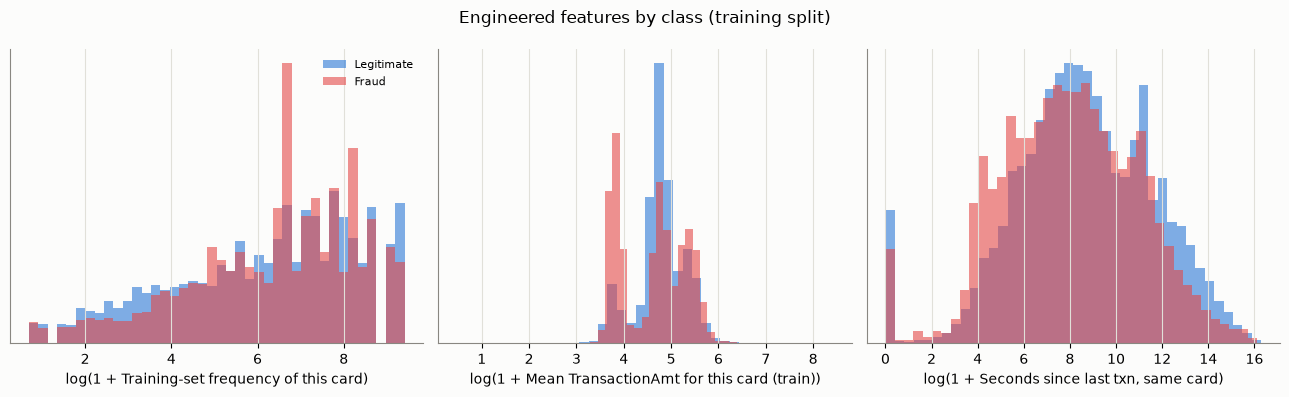

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col, xlabel in zip(
    axes,
    ["card1_frequency", "card1_mean_amount", "time_since_last_txn_same_card"],
    ["Training-set frequency of this card", "Mean TransactionAmt for this card (train)", "Seconds since last txn, same card"],
):
    data_legit = np.log1p(train_fe.loc[train_fe.isFraud == 0, col].clip(lower=0))
    data_fraud = np.log1p(train_fe.loc[train_fe.isFraud == 1, col].clip(lower=0))
    ax.hist(data_legit, bins=40, density=True, alpha=0.6, color=COLOR_LEGIT, label="Legitimate")
    ax.hist(data_fraud, bins=40, density=True, alpha=0.6, color=COLOR_FRAUD, label="Fraud")
    ax.set_xlabel(f"log(1 + {xlabel})")
    ax.set_yticks([])

axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Engineered features by class (training split)")
plt.tight_layout()
plt.show()

Fraud skews toward lower `card1_frequency` (less-established cards) and shorter `time_since_last_txn_same_card` (rapid repeat use) — exactly the kind of velocity signal these engineered features were meant to capture, and something the raw joined table doesn't expose directly.

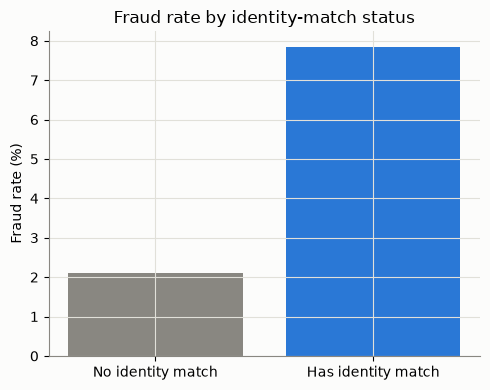

has_identity
0    2.093850
1    7.847025
Name: isFraud, dtype: float64

In [8]:
identity_fraud_rate = joined.groupby("has_identity")["isFraud"].mean() * 100

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["No identity match", "Has identity match"], identity_fraud_rate.values, color=[COLOR_MUTED, COLOR_SEQUENTIAL])
ax.set_ylabel("Fraud rate (%)")
ax.set_title("Fraud rate by identity-match status")
plt.tight_layout()
plt.show()

identity_fraud_rate

Fraud rate differs meaningfully by whether an identity record exists at all — confirming `has_identity` is worth keeping as an explicit feature rather than letting it disappear into per-field nulls.

## Correlation with target

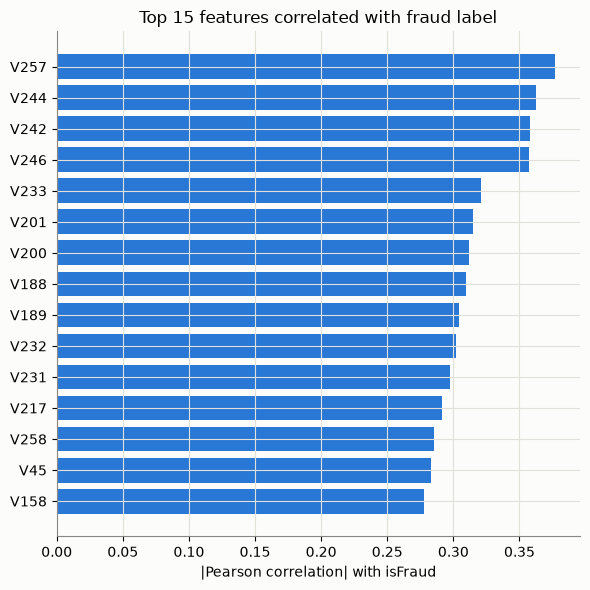

V257    0.376922
V244    0.362693
V242    0.357924
V246    0.357095
V233    0.321014
V201    0.314536
V200    0.311494
V188    0.309743
V189    0.304461
V232    0.301770
dtype: float64

In [9]:
numeric_cols = train_fe.select_dtypes(include="number").columns.drop(["isFraud", "TransactionID"])
corr_with_target = train_fe[numeric_cols].corrwith(train_fe["isFraud"]).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 6))
top15 = corr_with_target.head(15)
ax.barh(top15.index[::-1], top15.values[::-1], color=COLOR_SEQUENTIAL)
ax.set_xlabel("|Pearson correlation| with isFraud")
ax.set_title("Top 15 features correlated with fraud label")
plt.tight_layout()
plt.show()

corr_with_target.head(10)

The strongest single-feature correlations here (top: V257 at 0.377) are actually comparable to — even slightly higher than — the Kaggle PCA set's top feature (V17 at 0.327). That's a bit counter-intuitive given these are raw, non-decorrelated fields rather than components explicitly constructed to separate the classes. The more meaningful difference isn't the single-feature ceiling, it's that IEEE-CIS's signal is spread across many more moderately-correlated fields (V200s/V240s block, `card1_mean_amount`, `has_identity`) rather than concentrated in a handful of components — which is exactly the kind of dataset where feature engineering and nonlinear interactions (what XGBoost is for) earn their keep, rather than one dominant field carrying most of the separation.

## No-leakage checks

In [10]:
# 1. TransactionDT/TransactionAmt alone shouldn't trivially predict fraud.
weak_model = LogisticRegression(class_weight="balanced", max_iter=1000)
weak_model.fit(train_fe[["TransactionDT", "TransactionAmt"]], train_fe["isFraud"])
weak_auc = roc_auc_score(
    test_fe["isFraud"], weak_model.predict_proba(test_fe[["TransactionDT", "TransactionAmt"]])[:, 1]
)
print(f"ROC-AUC using ONLY TransactionDT + TransactionAmt: {weak_auc:.3f} (near 0.5 = no trivial leakage via these fields)")

# 2. No TransactionID appears on both sides of the time-aware split.
overlap = set(train_fe["TransactionID"]) & set(test_fe["TransactionID"])
print(f"TransactionIDs on both sides of the split: {len(overlap)}")

# 3. Category encoders were fit on train only — confirm test actually
#    contains categories genuinely unseen at fit time (as opposed to just
#    nulls, which both fillna(UNSEEN_CATEGORY_CODE) but aren't "leakage"
#    in the same sense), handled rather than silently leaking test-time
#    category information into the training-fit vocabulary.
from src.data.preprocess_ieee import fit_feature_encoders

encoders = fit_feature_encoders(train_df)
for col in ["P_emaildomain", "card4"]:
    known_categories = set(encoders["category_maps"][col].keys())
    test_values = test_df[col]
    is_null = test_values.isnull()
    is_genuinely_unseen = ~is_null & ~test_values.isin(known_categories)
    print(
        f"{col}: {is_null.sum()} null, {is_genuinely_unseen.sum()} genuinely unseen category "
        f"(both handled via UNSEEN_CATEGORY_CODE, not leaked from test)"
    )

ROC-AUC using ONLY TransactionDT + TransactionAmt: 0.509 (near 0.5 = no trivial leakage via these fields)
TransactionIDs on both sides of the split: 0


P_emaildomain: 20870 null, 0 genuinely unseen category (both handled via UNSEEN_CATEGORY_CODE, not leaked from test)
card4: 744 null, 0 genuinely unseen category (both handled via UNSEEN_CATEGORY_CODE, not leaked from test)


Same pattern as the Kaggle checks: the obviously-weak fields stay weak (no trivial shortcut to the label), the time-aware split has no ID overlap, and — the check specific to this dataset — feature encoders fit only on the training split genuinely encounter unseen categories at test time rather than having silently memorised the full vocabulary ahead of time.